### This jupyter notebook contains contents of the lesson "Clustering and unsupervised learning in ML"

**Author : Umidjon Sattorov. Machine Learning engineer**

Clustering - is type of machine learning problem where we cluster or classify dataset without any target variable. For this reason, we call the clustering as unsupervised learning in the field of Machine Learning. Because we don't provide any y value for ML model to work with. With it's own math, it should be able to cluster or classify data(Goal is group similar objects).

Example projects include : 

* Segmenting customers in marketing
* Grouping similar photos
* Finding related stocks in pair trading.

Clustering help us to discover hidden structure and also helps to reduce the number of features(complexity) of the data. Most popular and widely used algorithms of Clustering are k-means, hierchical clustering, dbscan and Gaussian Mixture Models(GMMs) and so on.

___

Because the clustering doesn't rely on the target variables, clustering method intensely relies on the distance between the data samples. For calculating distances, we use different formulas. In the following cells, I will demonstrate explanation of the CHATGPT for distance formulas.

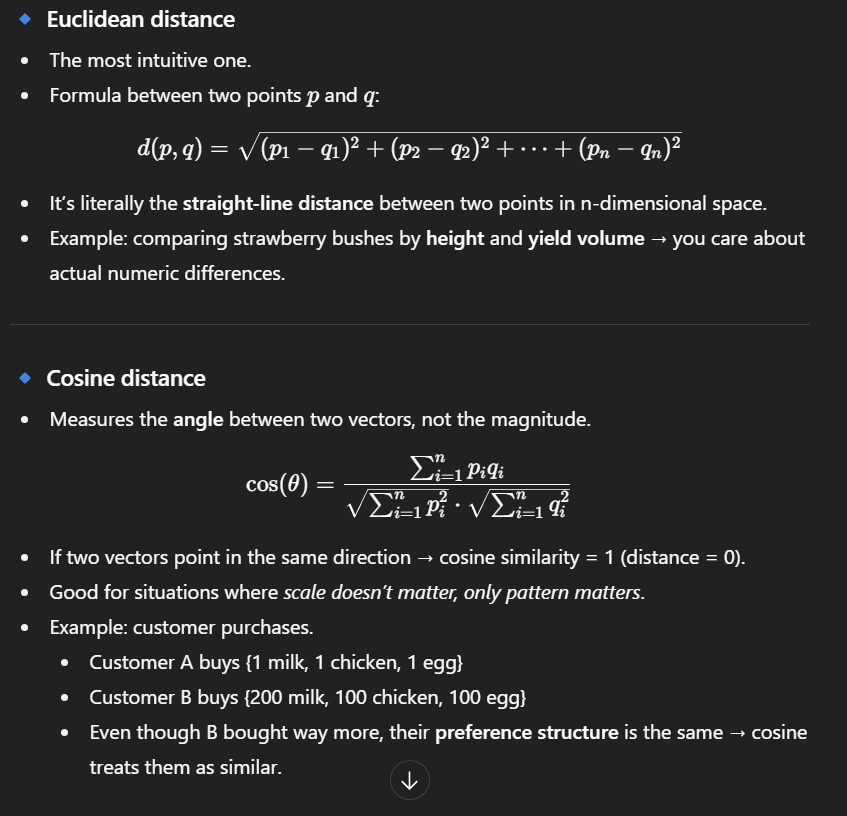

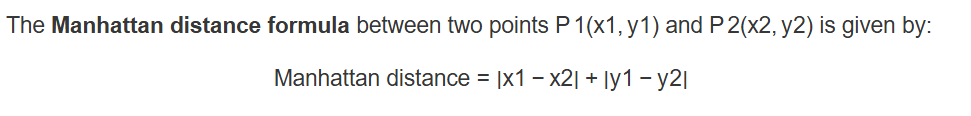

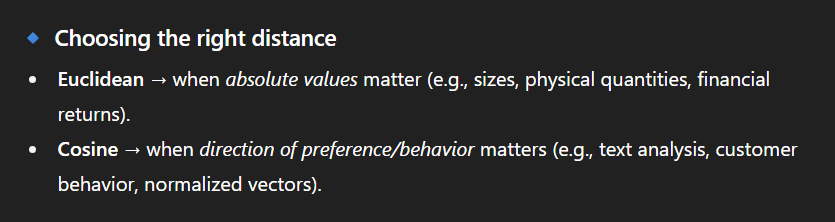

___

**K_Mean algorithms**

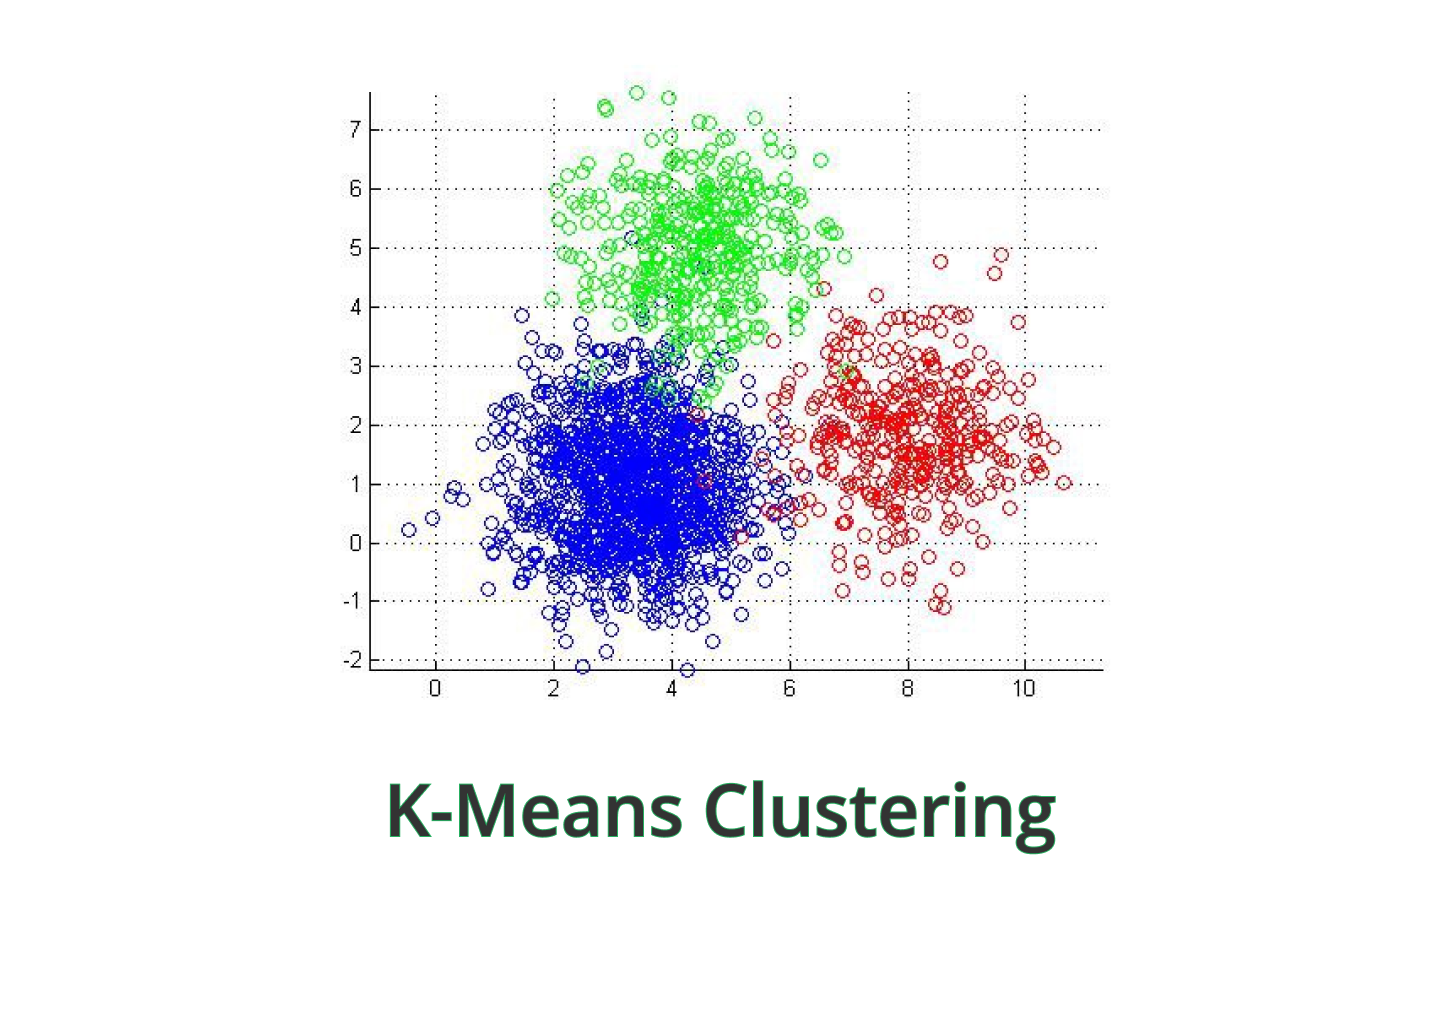

K-Means algorithm works firstly finding the k number of centroid for the given dataset. It's one of disadvantages is manual selection of the number for k(number of clusters we would like to group the data). But after selection, algorithms itself finds perfect centroids and their positions. Then it clusters the data with the centroids it found.

In [2]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy.spatial.distance import cdist

In [6]:
# Loading dataframe
df = pd.read_csv('data.csv')
df.head()

,Sum,Days,Color
0,22.072345,36.758307,1
1,37.936710,55.784810,1
2,21.083576,47.319176,1
3,31.120670,54.406780,1
4,43.711550,42.557729,1


In [7]:
for i in df:
    print(i)

Sum
Days
Color


In [8]:
df.shape

(3000, 3)

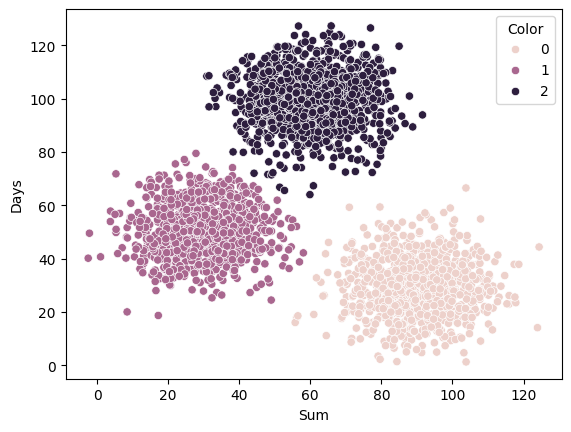

In [9]:
# Visualization of the dataset
sns.scatterplot(x = df['Sum'], y = df['Days'], hue = df['Color'])
plt.show()

Because in unsupervised learning, we cannot measure the quality of the model teachnically. However, there are some techniques which are applicable in unsupervised learning. But in this lesson, we use the dataset with y(target variable) to measure the performance as clustering methods can be used in classification, but classification models like Random Forest Classificator cannot be use without y variable.

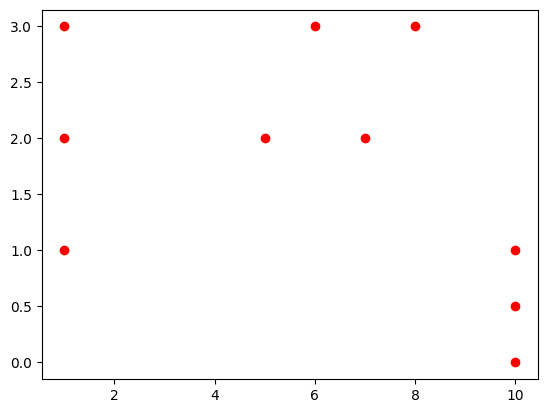

In [13]:
# Random data generation 
data = {
    'x' : [1, 1, 1, 10, 10, 10, 5, 6, 7, 8],
    'y' : [2, 3, 1, 1, 0.5, 0, 2, 3, 2, 3]
}
df_xy = pd.DataFrame(data)

# Visualize dataset
plt.scatter(df_xy['x'], df_xy['y'], c = 'red')
plt.show()

In [14]:
# Trying clustering using k_means algorithm
from sklearn.cluster import KMeans

km = KMeans(n_clusters = 3, random_state = 42)
km.fit(df_xy[['x', 'y']])

# Getting cluster centroids
centers = km.cluster_centers_
centers

array([[10. ,  0.5],
       [ 1. ,  2. ],
       [ 6.5,  2.5]])

In [15]:
# Checking cluster labels
km.labels_

array([1, 1, 1, 0, 0, 0, 2, 2, 2, 2], dtype=int32)

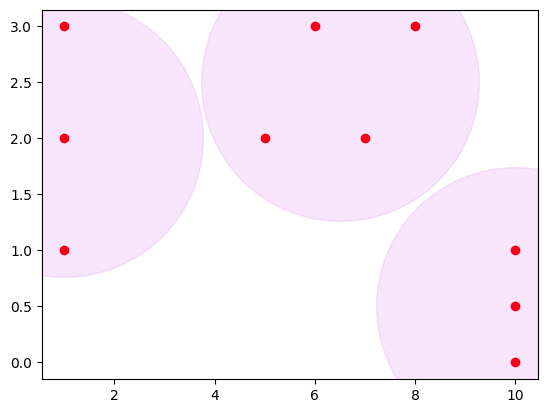

In [16]:
# Visualize dataset with cluster centroids
plt.scatter(df_xy['x'], df_xy['y'], c = 'red')
plt.scatter(centers[ : , 0], centers[ : , 1], c = '#B812DA', alpha = 0.1, s = 40000)
plt.show()

In [17]:
from scipy.spatial.distance import euclidean
import random

# Manual implementation of the k_means 
def random_centroids(number) :
    centroids_manual = []
    for i in range(number) :
        centroids_manual.append([random.uniform(df_xy['x'].min(), df_xy['x'].max()), random.uniform(df_xy['y'].min(), df_xy['y'].max())])
    return centroids_manual

rn_cents = random_centroids(3)
rn_cents

[[np.float64(6.34587477563928), np.float64(1.9168893283787392)],
 [np.float64(7.705575403554691), np.float64(0.7900620838418361)],
 [np.float64(4.728192609721326), np.float64(2.705785866688928)]]

In [18]:
# Calculating euclidian distance for each data
euc_dis = pd.DataFrame(columns = ['x', 'y', 'e1', 'e2', 'e3', 'cluster_number'])
for i in range(len(df_xy)) :
    euc_dis.loc[i, ['x', 'y']] = df_xy.iloc[i] 
    distances = [
        euclidean(rn_cents[0], df_xy.iloc[i].values),
        euclidean(rn_cents[1], df_xy.iloc[i].values),
        euclidean(rn_cents[2], df_xy.iloc[i].values)
    ]
    euc_dis.loc[i, ['e1', 'e2', 'e3']] = distances
    euc_dis.loc[i, 'cluster_number'] = np.argmin(distances) + 1
euc_dis

,x,y,e1,e2,e3,cluster_number
0,1.0,2.0,5.346521,6.81386,3.794411,3
1,1.0,3.0,5.454494,7.060352,3.739784,3
2,1.0,1.0,5.423934,6.708861,4.099893,3
3,10.0,1.0,3.767402,2.304009,5.540908,2
4,10.0,0.5,3.91921,2.312687,5.714669,2
5,10.0,0.0,4.12639,2.42664,5.925642,2
6,5.0,2.0,1.348438,2.963796,0.756315,3
7,6.0,3.0,1.136995,2.791561,1.305395,1
8,7.0,2.0,0.659384,1.400638,2.378916,1
9,8.0,3.0,1.977185,2.229464,3.285009,1


In [19]:
# Calculating new centroids for each clusters
new_cents = euc_dis.groupby(by = 'cluster_number')[['x', 'y']].mean()
new_cents

,x,y
cluster_number,,
1,7.0,2.666667
2,10.0,0.5
3,2.0,2.0


In [20]:
# Reiterating centroid's center, please be careful when using this part of the code
rn_cents = new_cents.values
rn_cents

array([[7.0, 2.6666666666666665],
       [10.0, 0.5],
       [2.0, 2.0]], dtype=object)

So when this iterations end, k_means ends it's operations and return it's centroids for data clustering.

___

Because I worked in the small dataset, it is time to you to do the same in the dataset I loaded firstly. Use your own math and then available the KMeans algorithm from the sklearn library.(In our work, we stopped finding new centroids when it stopped changing. In real life change happen all the time in every iteration. That is why use threshold value of 1e-4 to decide when to stop.)

    stop_criteria = (np.abs(old_centroids - centroids) > tol).sum() == 0

In [21]:
# Your code goes here
df = pd.read_csv('data.csv')
df.drop(columns=['Color'], inplace=True)
df

,Sum,Days
0,22.072345,36.758307
1,37.936710,55.784810
2,21.083576,47.319176
3,31.120670,54.406780
4,43.711550,42.557729
...,...,...
2995,105.652800,33.538939
2996,102.770880,37.626701
2997,84.465320,29.498640
2998,110.722820,27.744160


In [22]:
def random_centroids(number) :
    centroids_manual = []
    for i in range(number) :
        centroids_manual.append([random.uniform(df['Sum'].min(), df['Sum'].max()), random.uniform(df['Days'].min(), df['Days'].max())])
    return centroids_manual

rn_cents = random_centroids(3)
rn_cents

[[np.float64(85.29905167034897), np.float64(11.660745242125955)],
 [np.float64(83.1398934925322), np.float64(69.59874678356093)],
 [np.float64(16.360194487417203), np.float64(28.85907345992959)]]

In [23]:
euc_dis = pd.DataFrame(columns = ['Sum', 'Days', 'e1', 'e2', 'e3', 'cluster_number'])
for i in range(len(df)) :
    euc_dis.loc[i, ['Sum', 'Days']] = df.iloc[i] 
    distances = [
        euclidean(rn_cents[0], df.iloc[i].values),
        euclidean(rn_cents[1], df.iloc[i].values),
        euclidean(rn_cents[2], df.iloc[i].values)
    ]
    euc_dis.loc[i, ['e1', 'e2', 'e3']] = distances
    euc_dis.loc[i, 'cluster_number'] = np.argmin(distances) + 1
euc_dis

,Sum,Days,e1,e2,e3,cluster_number
0,22.072345,36.758307,68.02576,69.337868,9.748156,3
1,37.93671,55.78481,64.731171,47.266824,34.504222,3
2,21.083576,47.319176,73.451692,65.934557,19.054808,3
3,31.12067,54.40678,69.011017,54.192209,29.505202,3
4,43.71155,42.557729,51.808724,47.810155,30.590028,3
...,...,...,...,...,...,...
2995,105.6528,33.538939,29.881942,42.510477,89.415158,1
2996,102.77088,37.626701,31.296895,37.517827,86.854349,1
2997,84.46532,29.49864,17.857368,40.122005,68.108128,1
2998,110.72282,27.74416,30.083953,50.126084,94.369212,1


In [27]:
new_cents = euc_dis.groupby(by = 'cluster_number')[['Sum', 'Days']].mean()
new_cents

,Sum,Days
cluster_number,,
1,49.261776,73.000973
2,79.62005,9.175596
3,93.610854,34.505612


In [27]:
rn_cents = new_cents.values
rn_cents

array([[7.0, 2.6666666666666665],
       [10.0, 0.5],
       [2.0, 2.0]], dtype=object)

In [38]:
sum(sum(rn_cents - rn_cents))

0.0

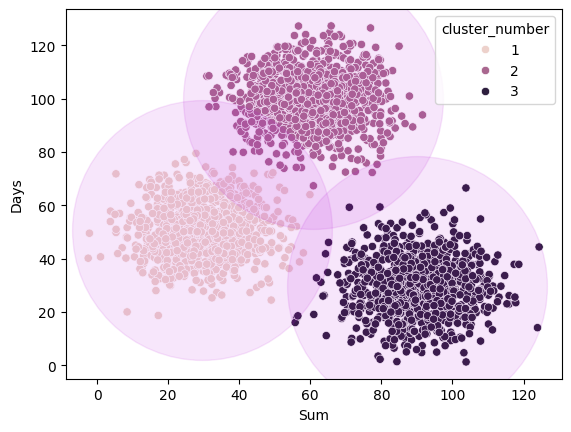

In [78]:
sns.scatterplot(x = df['Sum'], y = df['Days'], hue = euc_dis['cluster_number'])
plt.scatter(rn_cents[ : , 0], rn_cents[ : , 1], c = '#B812DA', alpha = 0.1, s = 35000)
plt.show()

In [79]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters = 3, random_state = 42)
km.fit(df)

# Getting cluster centroids
centers = km.cluster_centers_
centers

array([[60.68362784, 99.71589274],
       [89.92418447, 29.88035881],
       [29.4780459 , 50.686052  ]])

In [81]:
rn_cents

array([[29.47804589976643, 50.68605200481647],
       [60.68362784160135, 99.71589274151434],
       [89.92418447478977, 29.880358805638604]], dtype=object)

**Teacher warning : Teach elbow method** 

___

Based on the exploration of each work, can you create the class of KMeans algorithm on you own(Optional work).

In [ ]:
# Your code goes here


___

# Homework

## Задача

Пусть имеется набор данных `Mall_Customers.csv` о покупателях супермаркета:

* CustomerID — идентификатор покупателя;
* Genre — пол;
* Age — возраст;
* Annual Income (k$) — годовой доход покупателя в тыс. долл.;
* Spending Score (1–100) — рейтинг трат покупателя.

Решите задачу кластеризации покупателей, чтобы в дальнейшем планировать маркетинговые акции для каждой группы.

### Задание 1

Загрузите датасет и выполните разведочный анализ данных. Сделайте выводы о найденных закономерностях, особенностях и других обнаруженных свойствах данных.

In [46]:
# Your code goes here
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [50]:
df.drop(columns=['CustomerID'], inplace=True)

KeyError: "['CustomerID'] not found in axis"

### Задание 2

Метод k-средних требует явно задать количество кластеров, на которые будут разбиваться данные. Поскольку данных может быть настолько много, что построение одной модели будет занимать несколько часов, важно примерно оценить количество кластеров до запуска обучения модели.

На основе результатов разведочного анализа данных предположите, какое количество кластеров будет оптимальным, и аргументируйте предположение.

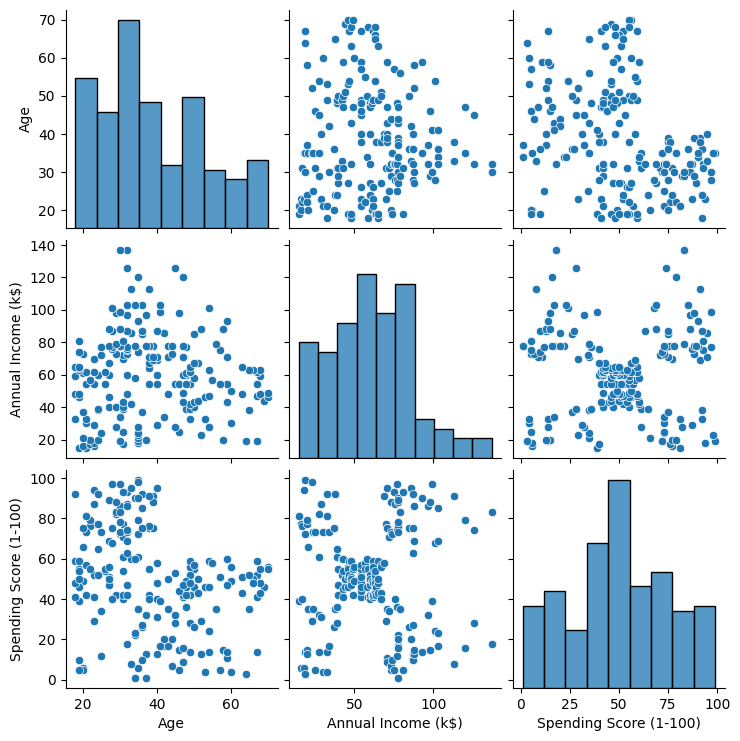

In [29]:
# Your code goes here
import seaborn as sns
sns.pairplot(df)

### Задание 3

Преобразуйте категориальный признак Genre в численный. Аргументируйте выбор метода кодирования признака.

In [51]:
# Your code goes here
df['Genre'] = [1 if i == 'Male' else 0 for i in df['Genre']]

### Задание 4

Постройте модель кластеризации с помощью метода k-средних. Определите оптимальное количество кластеров с помощью метода локтя.

In [31]:
# Your code goes here
from sklearn.cluster import KMeans

km = KMeans(n_clusters = 5, random_state = 42)
km.fit(df)

km.labels_

array([2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0,
       0, 4, 0, 0, 0, 4, 0, 0, 0, 0, 4, 0, 4, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

### Задание 5

Постройте финальную модель кластеризации с количеством кластеров, опредёленным в предыдущем задании.

In [32]:
# Your code goes here
wcss = []
for i in range(1, 15):
    km = KMeans(n_clusters = i, random_state = 42)
    km.fit(df)
    wcss.append(km.inertia_)

Text(0, 0.5, 'wcss')

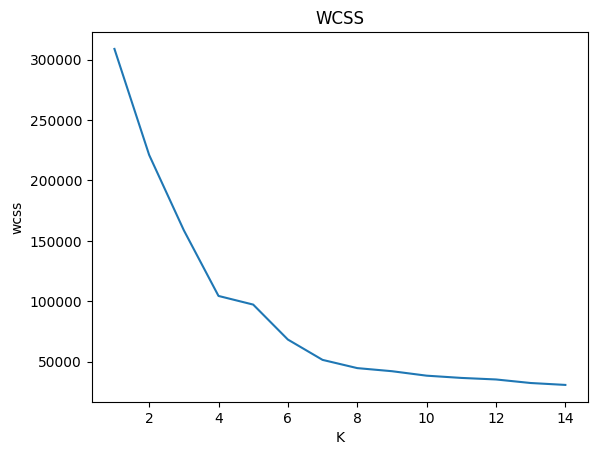

In [33]:
plt.Figure(figsize=(16, 10))
plt.title('WCSS')
plt.plot(range(1, 15), wcss)
plt.xlabel('K')
plt.ylabel('wcss')

In [34]:
km = KMeans(n_clusters = 8, random_state = 42)
km.fit(df)
km.labels_

array([5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4,
       5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 0, 4, 5, 6,
       5, 4, 0, 6, 6, 6, 0, 6, 6, 0, 0, 0, 0, 0, 6, 0, 0, 6, 0, 0, 0, 6,
       0, 0, 6, 6, 0, 0, 0, 0, 0, 6, 0, 6, 6, 0, 0, 6, 0, 0, 6, 0, 0, 6,
       6, 0, 0, 6, 0, 6, 6, 6, 0, 6, 0, 6, 6, 0, 0, 6, 0, 6, 0, 0, 0, 0,
       0, 6, 6, 6, 6, 6, 0, 0, 0, 0, 6, 6, 6, 2, 6, 2, 3, 2, 3, 2, 3, 2,
       6, 2, 3, 2, 3, 2, 3, 2, 3, 2, 6, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 7, 2, 7, 2, 7, 2, 7, 1, 7, 1, 7, 1, 7, 1, 7, 1, 7, 1,
       7, 1], dtype=int32)

### Задание 6 (выполните по желанию)

При работе с данными важно не только качество моделей машинного обучения, но и интерпретация полученных результатов и представление их в виде, понятном пользователям и заказчикам.

После построения модели кластеризации вы разбили покупателей на группы. Теперь важно интерпретировать эти группы, то есть создать профиль группы. 

В качестве профиля группы часто используют её типичного представителя. В кластерах типичным представителем можно назвать центроиду кластера. В sklearn получить список центроид можно с помощью атрибута `cluster_centers_` у объекта класса KMeans (этот атрибут возвращает матрицу с размерностями (количество кластеров, количество признаков), подробнее об этом [в материале](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)). 

Получите центроиды кластеров, преобразуйте их к датафрейму, опишите типичного представителя каждой группы и чем группы отличаются друг от друга. При описании и сравнении используйте методы визуализации.

In [ ]:
# Your code goes here


___

In [ ]:
class Kmeans:
    def __init__(self, n_clusters=8):
        self.n_clusters = n_clusters
    def fit(self, df):
        def random_centroids(number) :
            centroids_manual = []
            for i in range(number) :
                centroids_manual.append([random.uniform(df[i].min(), df[i].max()) for i in df])
            return centroids_manual
        
        rn_cents = random_centroids(self.n_clusters)
        rn_cents
        euc_dis = pd.DataFrame(columns=['cluster_number'])
        euc_dis = pd.concat([euc_dis, pd.DataFrame(columns = [f'e{i}' for i in range(len(df))])], axis=1)
        euc_dis = pd.concat([euc_dis, pd.DataFrame(columns=[i for i in df])], axis=1)
        for i in range(len(df)):
            euc_dis.loc[i, df.columns] = df.iloc[i] 
            distances = [euclidean(rn_cents[j], df.iloc[i].values) for j in range(len(rn_cents))]
            euc_dis.loc[i, [f'e{j}' for j in range(len(rn_cents))]] = distances
            euc_dis.loc[i, 'cluster_number'] = np.argmin(distances) + 1
        euc_dis
        new_cents = euc_dis.groupby(by = 'cluster_number')[[i for i in df]].mean()
        rn_cents = new_cents.values
        rn_cents
        while True:
            euc_dis = pd.DataFrame(columns=['cluster_number'])
            euc_dis = pd.concat([euc_dis, pd.DataFrame(columns = [f'e{i}' for i in range(len(rn_cents))])], axis=1)
            euc_dis = pd.concat([euc_dis, pd.DataFrame(columns=[i for i in df])], axis=1)
            for i in range(len(df)):
                euc_dis.loc[i, df.columns] = df.iloc[i] 
                distances = [euclidean(rn_cents[j], df.iloc[i].values) for j in range(len(rn_cents))]
                euc_dis.loc[i, [f'e{j}' for j in range(len(rn_cents))]] = distances
                euc_dis.loc[i, 'cluster_number'] = np.argmin(distances) + 1
            euc_dis
            new_cents = euc_dis.groupby(by = 'cluster_number')[[i for i in df]].mean()
            rn_cents0 = rn_cents
            rn_cents = new_cents.values
            if sum(sum(rn_cents0 - rn_cents)) == 0.0:
                break
        return rn_cents

In [71]:
a = Kmeans(2)

In [72]:
a.fit(df)

array([[0.43478260869565216, 46.165217391304346, 59.36521739130435,
        32.88695652173913],
       [0.4470588235294118, 28.95294117647059, 62.1764705882353,
        73.62352941176471]], dtype=object)

In [73]:
a.predict(df)

AttributeError: 'Kmeans' object has no attribute 'centroids'